In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost jupyterlab

Loading the Dataset 

In [5]:
import pandas as pd
import numpy as np

# Load the dataset of Youtube trending videos from Kaggle of the year 2025 and perform exploratory data analysis (EDA) 
# to understand the trends and patterns in the data.
df = pd.read_csv(r"C:\Users\rayal\Math Modelling\dataset\daily_trending_videos.csv")

# View the first 10 rows of the dataset to understand its structure and contents.
df.head(10)

,video_id,title,channel,country,views,likes,comments,published_at,fetch_date
0,KDorKy-13ak,Kendrick Lamar's Apple Music Super Bowl Halfti...,NFL,US,33079510,1633864,98574,2025-02-10T03:22:55Z,2025-02-11 17:43:34
1,lI4dq7ffQy0,Kendrick Lamar Disses Drake During Halftime Sh...,E! News,US,1475936,12629,5126,2025-02-10T03:27:44Z,2025-02-11 17:43:34
2,Y5vgBxUuNlc,JAZZ at LAKERS | FULL GAME HIGHLIGHTS | Februa...,NBA,US,1841263,31666,2906,2025-02-11T06:12:20Z,2025-02-11 17:43:34
3,hUUszE29jS0,Marvel Studios’ Thunderbolts* | Big Game Trail...,Marvel Entertainment,US,9893431,204063,13864,2025-02-09T23:54:00Z,2025-02-11 17:43:34
4,jdX5xwV829s,The First Kiss in Brawl Stars!?,Brawl Stars,US,8354717,257108,17632,2025-02-10T08:58:00Z,2025-02-11 17:43:34
5,Y-WbqjhRdGE,Telling our FAMILY & FRIENDS we’re pregnant!🥺,LIL JERZ,US,145054,12841,740,2025-02-11T00:59:52Z,2025-02-11 17:43:34
6,T_KZaJ744c4,T-Pain reacts to Kendrick Lamar’s Super Bowl H...,Nappy Boy Gaming,US,542460,34742,1711,2025-02-10T19:10:24Z,2025-02-11 17:43:34
7,qFuODmwJesU,Kendrick Lamar Had The Worst Super Bowl Perfor...,No Life Shaq,US,703272,40258,5948,2025-02-10T18:45:18Z,2025-02-11 17:43:34
8,axPGpMBZNx8,Top 10 Super Bowl Commercials of 2025,WatchMojo.com,US,448286,3129,2121,2025-02-10T15:15:49Z,2025-02-11 17:43:34
9,6ajnW0k0dM0,Kendrick Lamar's Super Bowl Performance Explai...,Bobby Foster,US,217159,12845,1269,2025-02-10T22:46:06Z,2025-02-11 17:43:34


Analyzing the Dataset 

In [6]:
# Check for missing values and data types 
# to identify any potential issues with the dataset and to plan for data cleaning and preprocessing steps.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 674141 entries, 0 to 674140
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   video_id      674141 non-null  str  
 1   title         674141 non-null  str  
 2   channel       674141 non-null  str  
 3   country       674141 non-null  str  
 4   views         674141 non-null  int64
 5   likes         674141 non-null  int64
 6   comments      674141 non-null  int64
 7   published_at  674141 non-null  str  
 8   fetch_date    674141 non-null  str  
dtypes: int64(3), str(6)
memory usage: 46.3 MB


In [7]:
# Get summary statistics of the dataset to understand the distribution and central tendencies of the numerical features,
# as well as the unique values and counts of categorical features.
# include = "all" is used to include all columns in the summary, regardless of their data type.
df.describe(include='all')

,video_id,title,channel,country,views,likes,comments,published_at,fetch_date
count,674141,674141,674141,674141,6.741410e+05,6.741410e+05,674141.000000,674141,674141
unique,52219,52866,16978,93,NaN,NaN,NaN,50341,13303
top,KDorKy-13ak,"Cool Items!🥰 New Gadgets, Smart Appliances, Ki...",MrBeast,GB,NaN,NaN,NaN,2025-02-10T03:22:55Z,2025-02-14 17:49:32
freq,962,1580,8029,7350,NaN,NaN,NaN,962,4650
mean,NaN,NaN,NaN,NaN,1.299674e+07,3.782878e+05,5755.019813,NaN,NaN
std,NaN,NaN,NaN,NaN,2.646282e+07,8.148719e+05,22499.916539,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,5.563680e+05,1.615000e+04,451.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,2.041075e+06,6.687800e+04,1446.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,1.155525e+07,3.358740e+05,3889.000000,NaN,NaN


In [12]:
print("Null values in each column:")
# isnull() is used to check for missing values in the dataset for each column, across the different rows
# sum() is used to count the total number of missing values in each column
# This helps to identify which columns have missing data and how many missing values are present
# This information is crucial for deciding how to handle missing data 
print(df.isnull().sum())
print("Unique values in each column:")
# nunique() is used to count the number of unique values in each column of the dataset
# This helps to understand the diversity of values in each column, 
# which is important for both numerical and categorical features
print(df.nunique())

Null values in each column:
video_id        0
title           0
channel         0
country         0
views           0
likes           0
comments        0
published_at    0
fetch_date      0
dtype: int64
Unique values in each column:
video_id         52219
title            52866
channel          16978
country             93
views           279471
likes           213557
comments         23486
published_at     50341
fetch_date       13303
dtype: int64


In [13]:
# Drop columns that are not relevant for analysis or modeling, such as "title" and "channel"
# to focus on the numerical features and reduce noise in the dataset.
df = df.drop(columns=["title", "channel"])

In [14]:
# Display the remaining columns in the dataset after dropping the irrelevant ones
# This is to confirm that the columns have been successfully removed, 
# which will be important for feature selection and modeling steps later on.
df.columns

Index(['video_id', 'country', 'views', 'likes', 'comments', 'published_at',
       'fetch_date'],
      dtype='str')

In [16]:
# Convert the "published_at" and "fetch_date" columns to datetime format for the analysis of date-related features.
df["published_at"] = pd.to_datetime(df["published_at"])
df["fetch_date"] = pd.to_datetime(df["fetch_date"])

In [17]:
# Confirm whether the conversion to datetime was successful by checking the data types of the columns again
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 674141 entries, 0 to 674140
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   video_id      674141 non-null  str                
 1   country       674141 non-null  str                
 2   views         674141 non-null  int64              
 3   likes         674141 non-null  int64              
 4   comments      674141 non-null  int64              
 5   published_at  674141 non-null  datetime64[us, UTC]
 6   fetch_date    674141 non-null  datetime64[us]     
dtypes: datetime64[us, UTC](1), datetime64[us](1), int64(3), str(2)
memory usage: 36.0 MB


In [20]:
# Sort the dataset by "video_id", "country", and "fetch_date" to organize the data in a meaningful way for analysis
# This works as hierarchical sorting, where the data is first sorted by "video_id", 
# then within each video_id by "country", and finally by "fetch_date"
df = df.sort_values(["video_id", "country", "fetch_date"])

In [21]:
# Display the first 15 rows of the sorted dataset to confirm that the sorting has been applied
df.head(15)

,video_id,country,views,likes,comments,published_at,fetch_date
202307,--16EpBdvIU,IN,1075692,54424,2220,2025-03-26 14:18:36+00:00,2025-03-27 11:09:11
206969,--16EpBdvIU,IN,1441211,64238,2581,2025-03-26 14:18:36+00:00,2025-03-28 11:09:11
211639,--16EpBdvIU,IN,1695013,71970,2788,2025-03-26 14:18:36+00:00,2025-03-29 11:08:05
651810,--DJ1N4xF2o,CZ,266682,11158,116,2025-06-25 17:30:01+00:00,2025-07-02 11:10:03
656427,--DJ1N4xF2o,CZ,311575,12817,119,2025-06-25 17:30:01+00:00,2025-07-03 11:09:53
661054,--DJ1N4xF2o,CZ,331185,13516,124,2025-06-25 17:30:01+00:00,2025-07-04 11:09:57
665684,--DJ1N4xF2o,CZ,348474,14178,134,2025-06-25 17:30:01+00:00,2025-07-05 11:08:37
670319,--DJ1N4xF2o,CZ,362498,14683,139,2025-06-25 17:30:01+00:00,2025-07-06 11:08:55
650316,--DJ1N4xF2o,SK,177170,7605,98,2025-06-25 17:30:01+00:00,2025-07-01 11:11:08
654928,--DJ1N4xF2o,SK,266682,11160,116,2025-06-25 17:30:01+00:00,2025-07-02 11:11:14


In [24]:
# First, group the dataset by "video_id" and "country"
# Then, calculate the difference in "views" between the consecutive rows within each group using the diff() function
# This will create a new column "growth" that represents the change in views for each video in each country over time
# This is the beginning step to convert the dataset into a time series format, which will be useful for modeling and forecasting the growth of views
df["growth"] = df.groupby(["video_id", "country"])["views"].diff()

In [25]:
# Display the first 15 rows of the sorted and grouped dataset with the new "growth" column 
# NaN values in the "growth" column will indicate the first entry for each video_id and country combination, 
# Where there is no previous row to calculate the difference from.
df.head(15)

,video_id,country,views,likes,comments,published_at,fetch_date,growth
202307,--16EpBdvIU,IN,1075692,54424,2220,2025-03-26 14:18:36+00:00,2025-03-27 11:09:11,NaN
206969,--16EpBdvIU,IN,1441211,64238,2581,2025-03-26 14:18:36+00:00,2025-03-28 11:09:11,365519.0
211639,--16EpBdvIU,IN,1695013,71970,2788,2025-03-26 14:18:36+00:00,2025-03-29 11:08:05,253802.0
651810,--DJ1N4xF2o,CZ,266682,11158,116,2025-06-25 17:30:01+00:00,2025-07-02 11:10:03,NaN
656427,--DJ1N4xF2o,CZ,311575,12817,119,2025-06-25 17:30:01+00:00,2025-07-03 11:09:53,44893.0
661054,--DJ1N4xF2o,CZ,331185,13516,124,2025-06-25 17:30:01+00:00,2025-07-04 11:09:57,19610.0
665684,--DJ1N4xF2o,CZ,348474,14178,134,2025-06-25 17:30:01+00:00,2025-07-05 11:08:37,17289.0
670319,--DJ1N4xF2o,CZ,362498,14683,139,2025-06-25 17:30:01+00:00,2025-07-06 11:08:55,14024.0
650316,--DJ1N4xF2o,SK,177170,7605,98,2025-06-25 17:30:01+00:00,2025-07-01 11:11:08,NaN
654928,--DJ1N4xF2o,SK,266682,11160,116,2025-06-25 17:30:01+00:00,2025-07-02 11:11:14,89512.0


In [26]:
# Fill the NaN values in the "growth" column with 0, 
# as the first entry for each video_id and country combination will have a growth of 0 (since there is no previous data to compare to).
df["growth"] = df["growth"].fillna(0)

In [27]:
# Calculate the acceleration of views by taking the difference of the "growth" column 
# within each group of "video_id" and "country"
df["acceleration"] = df.groupby(["video_id", "country"])["growth"].diff()

In [28]:
# Summary statistics of the "growth" column to understand the distribution of growth in views across the dataset,
# which can provide insights into the typical growth patterns and identify any outliers or trends in the data.
df["growth"].describe()

count    6.741410e+05
mean     8.516194e+05
std      2.638080e+06
min     -9.669280e+05
25%      7.847000e+03
50%      8.028700e+04
75%      4.579700e+05
max      5.742210e+07
Name: growth, dtype: float64

In [29]:
# Summary statistics of the "acceleration" column to understand the distribution of acceleration across the dataset,
# which can provide insights into the typical acceleration patterns and identify any outliers or trends in the data.
df["acceleration"].describe()

count    5.499220e+05
mean     9.273682e+04
std      2.254339e+06
min     -4.784484e+07
25%     -7.903725e+04
50%     -7.192000e+03
75%      2.896500e+04
max      5.742210e+07
Name: acceleration, dtype: float64

<Axes: >

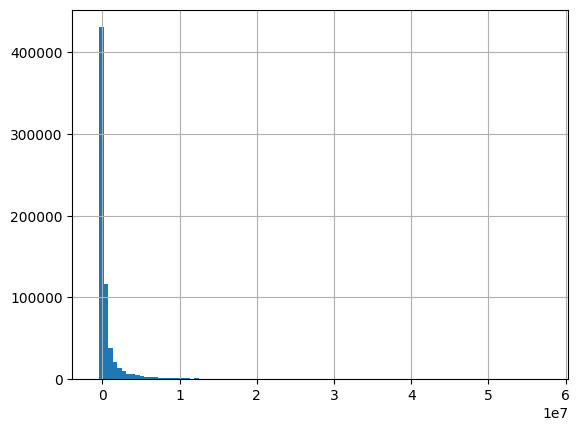

In [30]:
# Visualize the distribution of the "growth" column using a histogram with bins (interval size) set to 100 to 
# Understand the frequency of different growth values across the dataset,
# X axis = Growth values (change in views between two time points) and 
# Y axis = Frequency (How many rows fall into each interval of size 100)

# It is the distribution of ALL growth values across the entire dataset (global distribution), 
# not just the growth values for a specific video or country.
# each data point in the histogram = growth value for a specific video_id and country at a specific fetch_date
df["growth"].hist(bins=100)

In [31]:
# Converts the "views" column to a logarithmic scale using the natural logarithm (log1p) 
# For fair and smooth modeling, rather than using the raw "views" values
# For example, if a small video of 100 views grows to 200 views, it has doubled in popularity (100% growth),
# While a large video of 1 million views growing to 1.1 million views has only a 10% growth,
# But the raw growth in views is much larger for the second video (100,000 views) compared to the first video (100 views).
# Scale of the videos views can vary widely and not consistent, hence logarithmic transformation helps to normalize and 
# Stabilize the variance in the data, making it easier to model and analyze the growth patterns across videos of different sizes.
df["log_views"] = np.log1p(df["views"])

In [32]:
# Calculate the logarithmic growth by taking the difference of the "log_views" column
# within each group of "video_id" and "country"
df["log_growth"] = df.groupby(["video_id", "country"])["log_views"].diff()

In [ ]:
# Confirm that the new "log_views" and "log_growth" columns have been added to the dataset and check their data types
df.info()

<class 'pandas.DataFrame'>
Index: 674141 entries, 202307 to 460579
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   video_id      674141 non-null  str                
 1   country       674141 non-null  str                
 2   views         674141 non-null  int64              
 3   likes         674141 non-null  int64              
 4   comments      674141 non-null  int64              
 5   published_at  674141 non-null  datetime64[us, UTC]
 6   fetch_date    674141 non-null  datetime64[us]     
 7   growth        674141 non-null  float64            
 8   acceleration  549922 non-null  float64            
 9   log_views     674141 non-null  float64            
 10  log_growth    549922 non-null  float64            
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(4), int64(3), str(2)
memory usage: 61.7 MB


In [ ]:
# Calculate the logarithmic acceleration by taking the difference of the "log_growth" column
# within each group of "video_id" and "country"
# Growth = change in views between two time points, while Acceleration = change in growth between two time points
df["log_acceleration"] = df.groupby(["video_id","country"])["log_growth"].diff()

In [35]:
df.head(15)

,video_id,country,views,likes,comments,published_at,fetch_date,growth,acceleration,log_views,log_growth,log_acceleration
202307,--16EpBdvIU,IN,1075692,54424,2220,2025-03-26 14:18:36+00:00,2025-03-27 11:09:11,0.0,NaN,13.888476,NaN,NaN
206969,--16EpBdvIU,IN,1441211,64238,2581,2025-03-26 14:18:36+00:00,2025-03-28 11:09:11,365519.0,365519.0,14.180995,0.292519,NaN
211639,--16EpBdvIU,IN,1695013,71970,2788,2025-03-26 14:18:36+00:00,2025-03-29 11:08:05,253802.0,-111717.0,14.343202,0.162207,-0.130313
651810,--DJ1N4xF2o,CZ,266682,11158,116,2025-06-25 17:30:01+00:00,2025-07-02 11:10:03,0.0,NaN,12.493816,NaN,NaN
656427,--DJ1N4xF2o,CZ,311575,12817,119,2025-06-25 17:30:01+00:00,2025-07-03 11:09:53,44893.0,44893.0,12.649399,0.155583,NaN
661054,--DJ1N4xF2o,CZ,331185,13516,124,2025-06-25 17:30:01+00:00,2025-07-04 11:09:57,19610.0,-25283.0,12.710435,0.061037,-0.094546
665684,--DJ1N4xF2o,CZ,348474,14178,134,2025-06-25 17:30:01+00:00,2025-07-05 11:08:37,17289.0,-2321.0,12.761322,0.050886,-0.010151
670319,--DJ1N4xF2o,CZ,362498,14683,139,2025-06-25 17:30:01+00:00,2025-07-06 11:08:55,14024.0,-3265.0,12.800777,0.039455,-0.011431
650316,--DJ1N4xF2o,SK,177170,7605,98,2025-06-25 17:30:01+00:00,2025-07-01 11:11:08,0.0,NaN,12.084871,NaN,NaN
654928,--DJ1N4xF2o,SK,266682,11160,116,2025-06-25 17:30:01+00:00,2025-07-02 11:11:14,89512.0,89512.0,12.493816,0.408945,NaN


In [36]:
# Check for missing values in the "log_growth" and "log_acceleration" columns to understand how many rows have NaN values due to the differencing operation
# This is important to know before dropping the NaN values, as it will indicate how much data will be lost and whether it is significant for the analysis and modeling steps.
df = df.dropna(subset=["log_growth", "log_acceleration"])

In [37]:
df.head(10)

,video_id,country,views,likes,comments,published_at,fetch_date,growth,acceleration,log_views,log_growth,log_acceleration
211639,--16EpBdvIU,IN,1695013,71970,2788,2025-03-26 14:18:36+00:00,2025-03-29 11:08:05,253802.0,-111717.0,14.343202,0.162207,-0.130313
661054,--DJ1N4xF2o,CZ,331185,13516,124,2025-06-25 17:30:01+00:00,2025-07-04 11:09:57,19610.0,-25283.0,12.710435,0.061037,-0.094546
665684,--DJ1N4xF2o,CZ,348474,14178,134,2025-06-25 17:30:01+00:00,2025-07-05 11:08:37,17289.0,-2321.0,12.761322,0.050886,-0.010151
670319,--DJ1N4xF2o,CZ,362498,14683,139,2025-06-25 17:30:01+00:00,2025-07-06 11:08:55,14024.0,-3265.0,12.800777,0.039455,-0.011431
659551,--DJ1N4xF2o,SK,311575,12818,119,2025-06-25 17:30:01+00:00,2025-07-03 11:11:03,44893.0,-44619.0,12.649399,0.155583,-0.253363
664184,--DJ1N4xF2o,SK,331185,13517,124,2025-06-25 17:30:01+00:00,2025-07-04 11:11:08,19610.0,-25283.0,12.710435,0.061037,-0.094546
668819,--DJ1N4xF2o,SK,348474,14178,134,2025-06-25 17:30:01+00:00,2025-07-05 11:09:46,17289.0,-2321.0,12.761322,0.050886,-0.010151
673465,--DJ1N4xF2o,SK,362498,14683,139,2025-06-25 17:30:01+00:00,2025-07-06 11:10:05,14024.0,-3265.0,12.800777,0.039455,-0.011431
582070,--SAf4f-p1k,BR,9247586,310516,92,2025-06-15 05:42:42+00:00,2025-06-17 11:09:42,29485.0,-89440.0,16.039873,0.003193,-0.009792
10031,--UqxFlK4Ys,AZ,4104137,45558,2419,2025-02-04 21:15:50+00:00,2025-02-14 23:45:55,25762.0,-17114.0,15.227506,0.006297,-0.004272


<Axes: >

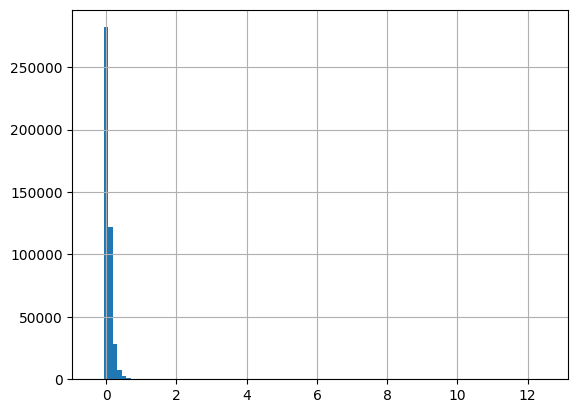

In [ ]:
# Visualize the distribution of the "log_growth" column using a histogram with bins (interval size) set to 100 to
# Understand the frequency of different logarithmic growth values across the dataset,
# X axis = Logarithmic Growth values (change in log views between two time points) and
# Y axis = Frequency (How many rows fall into each interval of size 100)    
df["log_growth"].hist(bins=100)

<Axes: xlabel='log_growth', ylabel='log_acceleration'>

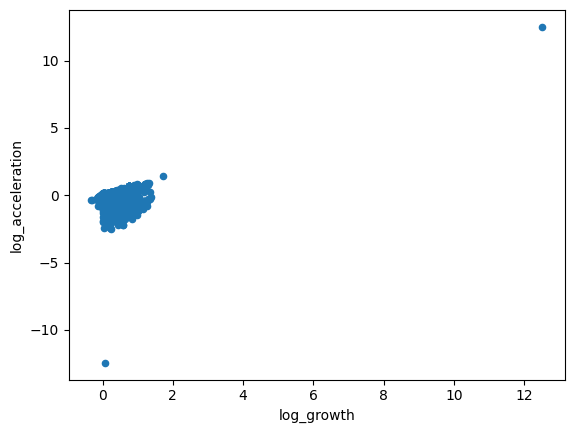

In [ ]:
# Visualize the relationship between "log_growth" and "log_acceleration" using a scatter plot 
# to understand how the growth and acceleration of views are related across the dataset
# Each point in the scatter plot represents a specific video_id and country at a specific fetch_date,
# with its corresponding log_growth and log_acceleration values.
df.plot.scatter(x="log_growth", y="log_acceleration")

In [ ]:
# Clip does not change the original values in the dataset, it only limits the values for visualization purposes.
# Clipping the "log_growth" and "log_acceleration" values to a range of -2 to 2 helps to focus on the 
# central part of the distribution and reduces the influence of extreme outliers in the scatter plot, 
# making it easier to visualize the overall relationship between growth and acceleration.
df["log_growth"] = df["log_growth"].clip(-2, 2)
df["log_acceleration"] = df["log_acceleration"].clip(-2, 2)

In [ ]:
# Correlation (rough signal of linearity)
# Correlation measures the strength and direction of a linear relationship between two variables.
df[["log_growth", "log_acceleration"]].corr()

,log_growth,log_acceleration
log_growth,1.000000,-0.568759
log_acceleration,-0.568759,1.000000


<Axes: xlabel='log_growth', ylabel='log_acceleration'>

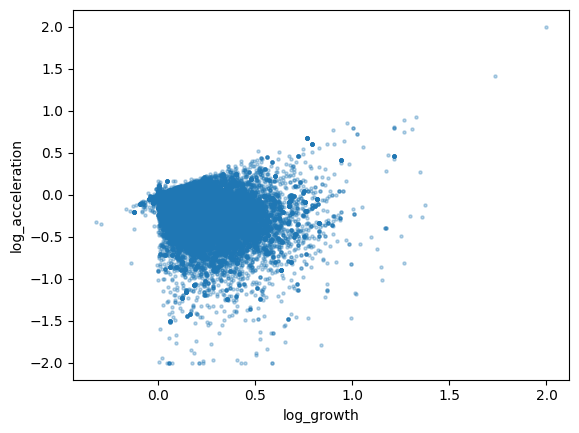

In [ ]:
# See spread after clipping
# s = size of the points in the scatter plot, alpha = transparency of the points to better visualize overlapping points
df.plot.scatter(x="log_growth", y="log_acceleration", s=5, alpha=0.3)

<Axes: >

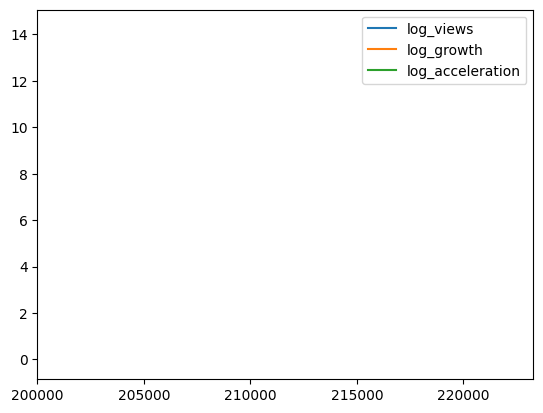

In [ ]:
# Visualize the growth and acceleration of views for a specific video_id across different countries and time points
# .iloc[0] is used to select the first video_id from the dataset for visualization purposes,
# but it can be changed to visualize other video_ids as well.
vid = df["video_id"].iloc[0]

#df[df["video_id"] == vid] is used to filter the DataFrame for the selected video_id, 
# with the condition that the "video_id" column matches the selected video_id (vid).
# that dataframe is then used to plot the "log_views", "log_growth", and "log_acceleration" columns 
# to visualize how these metrics evolve over time for that specific video_id across different countries.
df[df["video_id"] == vid][["log_views","log_growth","log_acceleration"]].plot()

In [ ]:
# The above plot has no clear trend because the selected video_id may not have enough data points 
# across different countries and time points to show a clear pattern in growth and acceleration.
# To address this, we can filter the dataset to include only those video_id and country combinations that have at least 3 data points,
# which will provide a more meaningful visualization of the growth and acceleration patterns for those videos.

# Group the dataset by "video_id" and "country", then filter the groups to include only those that have at least 3 rows (data points).
df = df.groupby(["video_id","country"]).filter(lambda x: len(x) >= 3)

<Axes: >

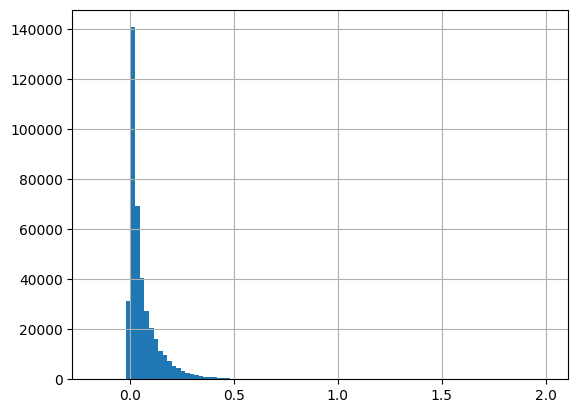

In [ ]:
# Replot the histogram of "log_growth" after filtering the dataset to see 
# how the distribution looks with only those video_id and country combinations that have at least 3 data points.
df["log_growth"].hist(bins=100)

<Axes: xlabel='log_growth', ylabel='log_acceleration'>

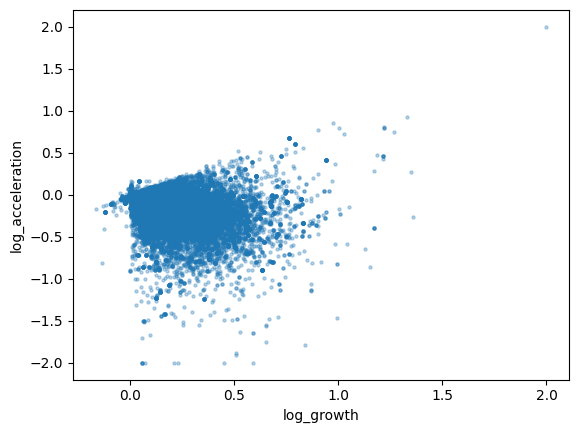

In [ ]:
# Replot the scatter plot of "log_growth" vs "log_acceleration" after filtering the dataset to see
# how the relationship looks with only those video_id and country combinations that have at least 3 data points.
df.plot.scatter(x="log_growth", y="log_acceleration", s=5, alpha=0.3)

In [47]:
df[["log_growth","log_acceleration"]].corr()

,log_growth,log_acceleration
log_growth,1.000000,-0.581152
log_acceleration,-0.581152,1.000000


<Axes: xlabel='fetch_date'>

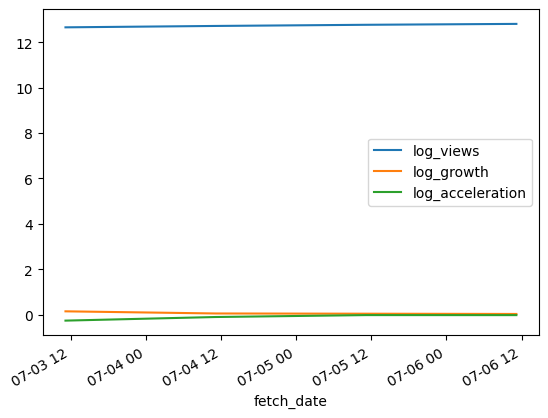

In [ ]:
# Filter the dataset for the selected video_id, 
# sort it by "fetch_date", and 
# plot the "log_views", "log_growth", and "log_acceleration" columns over time 
# to visualize how these metrics evolve for that specific video_id across different countries.
df[df["video_id"] == vid].sort_values("fetch_date")[[
    "fetch_date", "log_views","log_growth","log_acceleration"
]].plot(x="fetch_date")

# Here, the log_views, log_growth, and log_acceleration for the selected video_id are plotted over time (fetch_date) 
# to visualize how these metrics evolve for that specific video_id across different countries.
# The problem here is, all three plots are like a constant line, indicating that there may not be enough variation 
# in the data for that specific video_id across the different time points and countries 
# to show a clear trend in growth and acceleration.

In [ ]:
# To address this, we can identify the top 10 video_id and country combinations with the highest maximum log_growth values,
# which will likely have more variation in their growth and acceleration patterns,
# and then visualize those specific combinations to see clearer trends in growth and acceleration over time.
top_videos = df.groupby(["video_id","country"])["log_growth"].max() \
               .sort_values(ascending=False).head(10)

top_videos

video_id     country
suaJf7hfIyE  SE         2.000000
uXaKPa-AaII  FI         1.358676
ujjKvWb98ZM  SN         1.348081
7tX1Jy7VLP0  KZ         1.328012
VGdwptuZaRA  PH         1.265663
MZv8L89w1eI  EE         1.216979
             PL         1.216979
             LT         1.216979
34egDsvYvKU  NL         1.215239
GtpTXgJHv7A  SA         1.215163
Name: log_growth, dtype: float64

In [ ]:
# The top 10 video_id and country combinations with the highest maximum log_growth values are identified,
# which will likely have more variation in their growth and acceleration patterns,
# and then we can visualize those specific combinations to see clearer trends in growth and acceleration over time
# .index[0][0] is used to select the video_id of the top video, and 
# .index[0][1] is used to select the country of the top video from the top_videos Series.
vid = top_videos.index[0][0]
country = top_videos.index[0][1]

df_video = df[(df["video_id"] == vid) & (df["country"] == country)]

array([<Axes: xlabel='fetch_date'>, <Axes: xlabel='fetch_date'>,
       <Axes: xlabel='fetch_date'>], dtype=object)

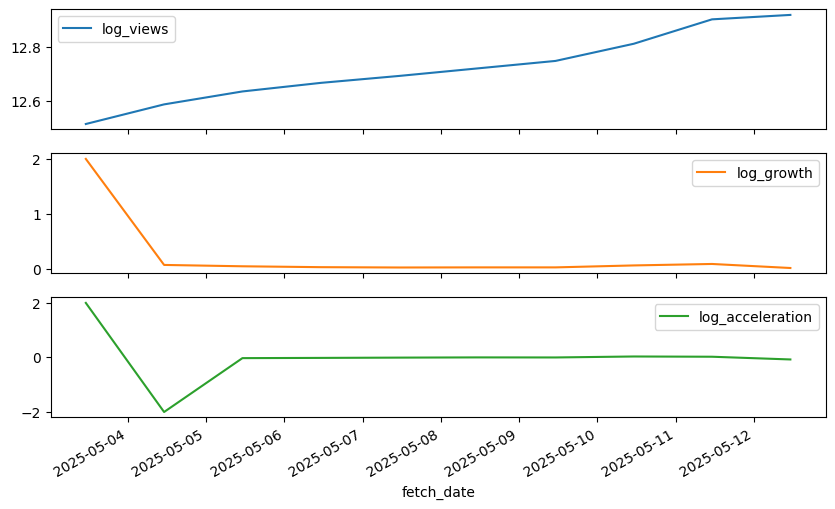

In [ ]:
# Filter the dataset for the selected video_id and country,
# sort it by "fetch_date", and
# plot the "log_views", "log_growth", and "log_acceleration" columns over time 
# to visualize how these metrics evolve for that specific video_id across different countries.

# .plot(subplots=True) is used to create separate subplots for each of the columns being plotted,
# x ="fetch_date" is used to set the x-axis to the "fetch_date"
# figsize=(10,6) is used to set the size of the overall figure for better visualization of the three subplots.
df_video.sort_values("fetch_date")[[
    "fetch_date","log_views","log_growth","log_acceleration"
]].plot(subplots=True, x="fetch_date", figsize=(10,6))